# Tennis Match Predictor

The goal of this project is to analyze different machine learning models for predicting the outcome of a tennis match.

## Contents

1. **Data loading** 
2. **Exploratory data analysis** 
3. **Data cleaning**
4. **Train/test split**
5. **Feature engineering**
6. **Training and evaluation** 
    - **Logistic Regression**   `src/notebooks/logistic_regression.ipynb`
    - **Random Forest**         `src/notebooks/random_forest.ipynb`
    - **XGBoost**               `src/notebooks/xgboost.ipynb`

The implementation used in these notebooks lives in the `src/` package.

# Setup & Imports

In [24]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent 
sys.path.append(str(PROJECT_ROOT))

import pandas as pd

from src.data.loader import load_data, train_test_split
from src.utils.utils import get_df_from_pipeline
from src.data.preprocess import (
    preprocessing_pipeline, 
    create_labels
)
from src.evaluation.plots import plot_top100, plot_rank_difference

from src.features.features import feature_engineering_pipeline


# Data Loading

Loading professional (ATP) tennis single matches played between 2017 and 2025 published by [tennis-data.co.uk](http://tennis-data.co.uk/) as one file per season.

`load_data()` concatenate them into a single DataFrame by merging raw files into a single chronologically sorted dataset based on match date.

In [25]:
raw_df : pd.DataFrame = load_data()
raw_df.head().transpose()

,0,1,2,3,4
ATP,1,1,1,1,1
Location,Brisbane,Brisbane,Brisbane,Brisbane,Brisbane
Tournament,Brisbane International,Brisbane International,Brisbane International,Brisbane International,Brisbane International
Date,2017-01-01 00:00:00,2017-01-02 00:00:00,2017-01-02 00:00:00,2017-01-02 00:00:00,2017-01-02 00:00:00
Series,ATP250,ATP250,ATP250,ATP250,ATP250
Court,Outdoor,Outdoor,Outdoor,Outdoor,Outdoor
Surface,Hard,Hard,Hard,Hard,Hard
Round,1st Round,1st Round,1st Round,1st Round,1st Round
Best of,3.0,3.0,3.0,3.0,3.0
Winner,Thompson J.,Mahut N.,Ferrer D.,Edmund K.,Dimitrov G.


# Exploratory Data Analysis

Before proceeding with any data manipulation, we first examine the dataset to gain insights

## Columns

In [26]:
print(raw_df.columns.tolist())
print(len(raw_df.columns))

['ATP', 'Location', 'Tournament', 'Date', 'Series', 'Court', 'Surface', 'Round', 'Best of', 'Winner', 'Loser', 'WRank', 'LRank', 'WPts', 'LPts', 'W1', 'L1', 'W2', 'L2', 'W3', 'L3', 'W4', 'L4', 'W5', 'L5', 'Wsets', 'Lsets', 'Comment', 'B365W', 'B365L', 'EXW', 'EXL', 'LBW', 'LBL', 'PSW', 'PSL', 'MaxW', 'MaxL', 'AvgW', 'AvgL', 'BFEW', 'BFEL']
42


This dataset contains 42 columns of the following information about tennis matches:

- Tournament Information
    - ATP: Tournament number
    - Location: Venue of the tournament
    - Tournament: Name of the tournament
    - Date: Date of the match
    - Series: ATP tournament category
- Match Conditions
    - Court: Court type
    - Surface: Surface type
    - Round: Stage of the tournament
    - Best of: Maximum number of sets played in the match
- Players
    - Winner: Match winner
    - Loser: Match loser
    - WRank: ATP ranking of the winner at tournament start
    - LRank: ATP ranking of the loser at tournament start
    - WPts: ATP ranking points of the winner at tournament start
    - LPts: ATP ranking points of the loser at tournament start
- Match Score
    - W1, L1: Games won by winner/loser in the 1st set
    - W2, L2: Games won by winner/loser in the 2nd set
    - W3, L3: Games won by winner/loser in the 3rd set
    - W4, L4: Games won by winner/loser in the 4th set
    - W5, L5: Games won by winner/loser in the 5th set
    - Wsets: Total sets won by the match winner
    - Lsets: Total sets won by the match loser
    - Comment: Match outcome note
- Bets — odds for the winner (`*W`) and the loser (`*L`) of the match

## Values

As we can see from the output of `info()` function, we need to take care of missing values.

In [27]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22318 entries, 0 to 22317
Data columns (total 42 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ATP         22318 non-null  int64         
 1   Location    22318 non-null  str           
 2   Tournament  22318 non-null  str           
 3   Date        22318 non-null  datetime64[us]
 4   Series      22318 non-null  str           
 5   Court       22318 non-null  str           
 6   Surface     22318 non-null  str           
 7   Round       22318 non-null  str           
 8   Best of     22303 non-null  float64       
 9   Winner      22318 non-null  str           
 10  Loser       22318 non-null  str           
 11  WRank       22311 non-null  float64       
 12  LRank       22273 non-null  float64       
 13  WPts        22312 non-null  float64       
 14  LPts        22273 non-null  float64       
 15  W1          22163 non-null  float64       
 16  L1          22166 non-null  float

As we can see, most of the bet columns contain missing values, as do some of the game-related columns, such as `W4`, `L4`, `W5`, and `L5`.

In [28]:
missing = raw_df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

BFEL       21667
BFEW       21667
L5         21455
W5         21455
L4         19996
W4         19996
LBW        17791
LBL        17789
EXW        17080
EXL        17080
L3         11522
W3         11522
L2           318
W2           317
PSW          209
PSL          209
Lsets        156
W1           155
Wsets        153
L1           152
B365L         93
B365W         93
LPts          45
LRank         45
MaxW          20
MaxL          20
AvgW          20
AvgL          20
Best of       15
WRank          7
WPts           6
dtype: int64


The following code checks for rows where one betting-odds value (MaxW/MaxL or AvgW/AvgL) is present while its corresponding value is missing.

The result is empty, indicating that there are no partially missing odds pairs in the dataset, therefore during preprocessing
we can safely use the same imputer to fill missing odds values with a constant value.

In [29]:
mask = (
    (raw_df["MaxW"].notna() & raw_df["MaxL"].isna()) |
    (raw_df["MaxW"].isna() & raw_df["MaxL"].notna()) |
    (raw_df["AvgW"].notna() & raw_df["AvgL"].isna()) |
    (raw_df["AvgW"].isna() & raw_df["AvgL"].notna()) 
)

print(raw_df[mask])

Empty DataFrame
Columns: [ATP, Location, Tournament, Date, Series, Court, Surface, Round, Best of, Winner, Loser, WRank, LRank, WPts, LPts, W1, L1, W2, L2, W3, L3, W4, L4, W5, L5, Wsets, Lsets, Comment, B365W, B365L, EXW, EXL, LBW, LBL, PSW, PSL, MaxW, MaxL, AvgW, AvgL, BFEW, BFEL]
Index: []

[0 rows x 42 columns]


The rows with missing values in the set columns cannot be imputed using the information of the game columns, therefore it is reasonable to drop them during preprocessing.

In [30]:
mask = (raw_df["Wsets"].isna() | raw_df["Lsets"].isna())

print(
    raw_df.loc[mask, ["W1", "L1", "W2", "L2", "W3", "L3"]]
    .sort_values(by=["W1", "L1"])
    .to_string(index=False)
)

 W1  L1  W2  L2  W3  L3
1.0 0.0 NaN NaN NaN NaN
4.0 1.0 NaN NaN NaN NaN
NaN 2.0 NaN NaN NaN NaN
NaN 2.0 NaN NaN NaN NaN
NaN 3.0 NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN NaN NaN
NaN NaN NaN NaN 

## Values Distributions

By looking at match statistics using the `describe()` function, we can gain some insights about the values in the dataset:
- Match Format:
    - Most matches are best of 3 sets, this also explains the high amount of null values in the `W4`, `L4`, `W5`, `L5` columns
- Rank/Points:
    - Matches in the dataset are mostly played by top 100 players, since they tipically play more matches in a tournament
    - The median of WRank and LRank indicates that winners are generally better ranked than losers. This statement is valid also for the points.
- Sets/Games:
    - Winning the first set is a strong predictor of winning the match, as the distribution of `W1` shows.
    - Over 50% of best of 3 matches don't go beyond 2 sets

In [31]:
raw_df.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
ATP,22318.0,31.803835,1.0,18.0,31.0,48.0,68.0,17.970181
Date,22318,2021-07-03 13:16:04.279953,2017-01-01 00:00:00,2019-02-06 06:00:00,2021-08-31 12:00:00,2023-10-18 00:00:00,2025-11-16 00:00:00,NaN
Best of,22303.0,3.397884,3.0,3.0,3.0,3.0,5.0,0.798426
WRank,22311.0,60.439962,1.0,17.0,44.0,80.0,1821.0,72.280304
LRank,22273.0,90.003996,1.0,35.0,63.0,102.0,4915.0,125.692819
WPts,22312.0,1892.990588,1.0,727.0,1101.0,2200.0,12560.0,2047.07168
LPts,22273.0,1209.318502,1.0,595.0,864.0,1322.0,12560.0,1244.176051
W1,22163.0,5.806434,0.0,6.0,6.0,6.0,7.0,1.237365
L1,22166.0,4.182442,0.0,3.0,4.0,6.0,8.0,1.810965
W2,22001.0,5.778965,0.0,6.0,6.0,6.0,7.0,1.262215


Insights can be visualized with the following histograms

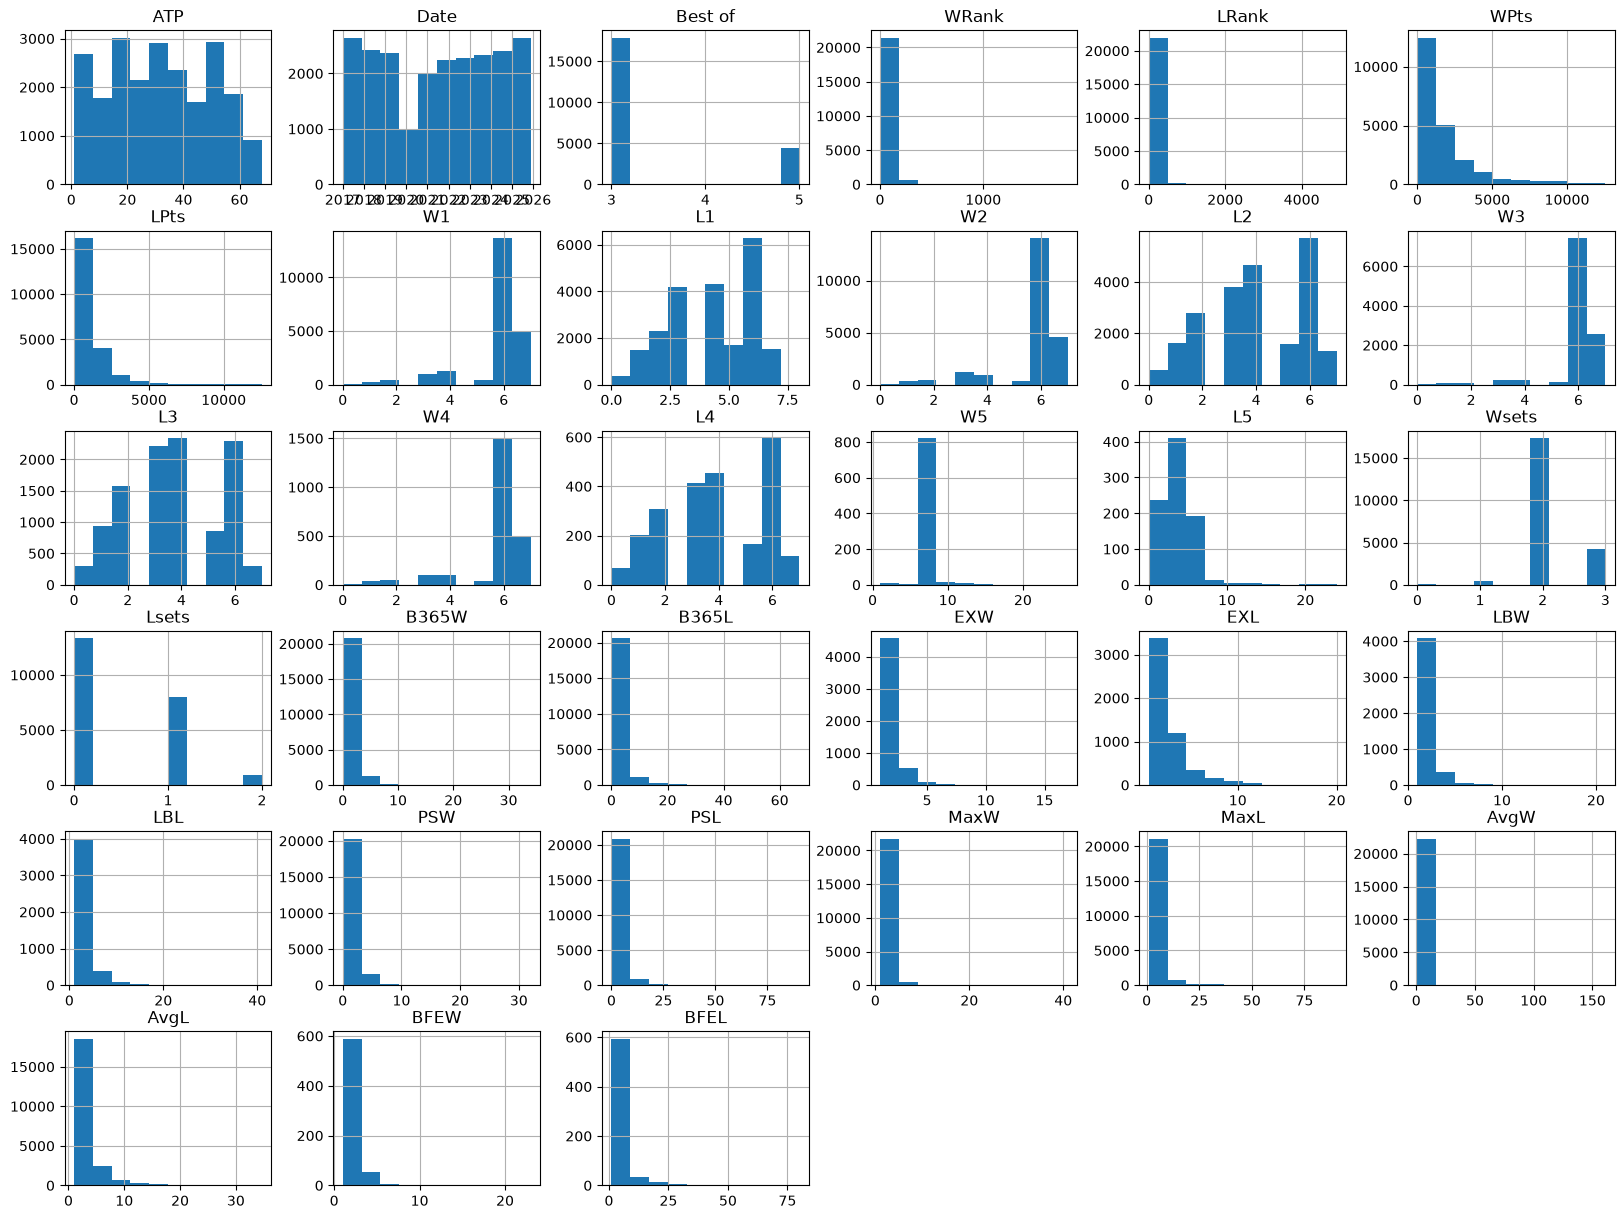

In [32]:
raw_df.hist(figsize=(20, 15));

As we can see from the density of matches, most matches are played by top ranked players.

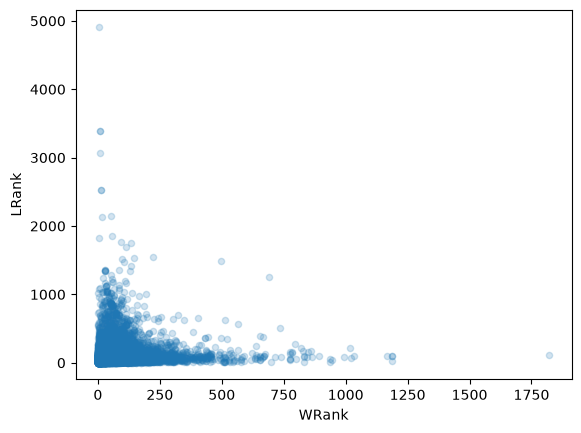

In [33]:
raw_df.plot(kind="scatter", x="WRank", y="LRank", alpha=0.2);

### Winner - Loser Ranking plot

The chart below shows the relationship between the winner and loser rankings, and we can clearly see that an higher ranking means more wins and more matches played.

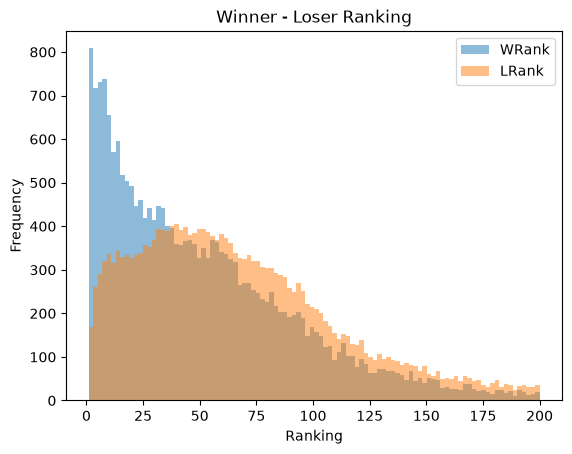

In [34]:
plot_rank_difference(raw_df)

Here, we can see that the difference in ranking is more significant among higher-ranked players. For instance, the same 20-position difference has a greater impact between players ranked 1st and 20th than between players ranked 80th and 100th.

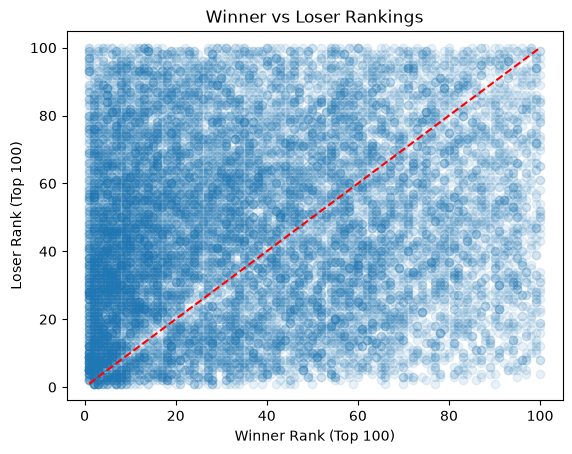

In [35]:
plot_top100(raw_df)

## Values Range

### Comment

In [36]:
raw_df["Comment"].value_counts(dropna=False)

Comment
Completed       21548
Retired           618
Walkover          144
Awarded             5
Sched               1
Disqualified        1
Rrtired             1
Name: count, dtype: int64

The `Comment` column records how a match ended, these are the values that can appear:

- **Completed** — the match was played to its natural end, one player won the required number of sets on court. It's the only outcome whose score and statistics are fully reliable.
- **Retired** — the match started but a player withdrew while it was in progress (injury, illness). The winner is decided by the retirement, not by the score, so games and sets recorded are only the portion played before the withdrawal.
- **Walkover** — a player withdrew *before* the first point, so the match was never played: there is no score and the result carries no information about the two players.
- **Awarded** — the win was assigned by the officials after a mid-match default.
- **Disqualified** — same situation as *Awarded*, recorded under a different label by the data provider.
- **Sched** - the match was scheduled but never played, so there is no score and the result carries no information about the two players.
- **Rrtired** — a typo of *Retired* in the source file

Therefore the matches which outcome was Walkover, Awarded, Sched or Disqualified do not provide any information about the match itself and since there are very few of them, we can drop them in the preprocessing step. 

### Surface

In [37]:
raw_df["Surface"].value_counts(dropna=False)

Surface
Hard     12996
Clay      6784
Grass     2538
Name: count, dtype: int64

### Round

In [38]:
raw_df["Round"].value_counts(dropna=False)

Round
1st Round        9925
2nd Round        6400
Quarterfinals    2168
3rd Round        1568
Semifinals       1102
The Final         551
4th Round         496
Round Robin       108
Name: count, dtype: int64

### Court

In [39]:
raw_df["Court"].value_counts(dropna=False)

Court
Outdoor    18464
Indoor      3854
Name: count, dtype: int64

### Series

In [40]:
raw_df["Series"].value_counts(dropna=False)

Series
ATP250          9171
Masters 1000    5062
Grand Slam      4445
ATP500          3505
Masters Cup      135
Name: count, dtype: int64

### Tournament

In [41]:
raw_df["Tournament"].value_counts(dropna=False)

Tournament
Australian Open                       1143
French Open                           1143
US Open                               1143
Wimbledon                             1016
BNP Paribas Open                       760
                                      ... 
Napoli Cup                              27
Srpska Open                             27
Zhuhai Championships                    27
U.S.Men's Clay Court Championships      27
Hellenic Championship                   27
Name: count, Length: 128, dtype: int64

## Data Cleaning

The raw data is recorded *from the outcome's point of view*: every row has a `Winner` and a `Loser`, and every statistic of the match comes as a winner/loser pair (`WRank`/`LRank`, `WPts`/`LPts`, `MaxW`/`MaxL`, ...). Therefore the answer is encoded in the column layout itself, and a model trained on it as-is would simply learn "the first player always wins".

To solve the problem, in the function `create_lables()` each match is re-encoded around two general players, `player1` and `player2`, assigned with a fair coin flip. Every winner/loser column pair is swapped consistently based on the coin flip, and the target generated is a binary variable `winner`:

$$\texttt{winner} = \begin{cases} 1 & \text{if player1 won the match} \\ 0 & \text{otherwise} \end{cases}$$

In [42]:
cleaned_df = raw_df.copy()
create_labels(cleaned_df)
cleaned_df["winner"].value_counts(dropna=False)

winner
0    11247
1    11071
Name: count, dtype: int64

## Train Test Split

`train_test_split` (in `src/data/loader.py`) is performed with a 80/20 ratio based on the match date, avoiding data leakage.

In [52]:
X_train, X_test, y_train, y_test = train_test_split(cleaned_df)

print(f"dataset shape: {cleaned_df.shape}" )
print(f"X_train shape: {X_train.shape}" )
print(f"X_test shape: {X_test.shape}" )
print(f"y_train shape: {y_train.shape}" )
print(f"y_test shape: {y_test.shape}" )

dataset shape: (22318, 44)
X_train shape: (17854, 43)
X_test shape: (4464, 43)
y_train shape: (17854,)
y_test shape: (4464,)


## Preprocessing

`preprocessing_pipeline` builds the scikit-learn `Pipeline` that turns the raw DataFrame into a cleaned one.

### Row filtering (before the pipeline)

Some rows are removed in place from `X`/`y` *before* the pipeline is assembled if they satisfy one of these conditions:

- **Comment** (`Comment == "Awarded" or Comment == "Walkover" or Comment == "Disqualified" or Comment == "Sched"`), matches that were partially played and whose "result" says nothing about the two players, as we said above these are very few and can be dropped without losing much information.
- **matches with no set count** (`player1_sets`/`player2_sets` missing), as described above,
these rows cannot be imputed using the information of the game columns, therefore it is reasonable to drop them.

### The pipeline steps

**1. `fix_typos` — `ReplaceValuesTransformer`.** Fixes typos in the `Comment` column, replacing `Rrtired` with `Retired`

**2. `drop_cols` — `DropFeatureSelector`.** Drops bet columns with high rate of missing values

**3. `rank_points_imputer` — `RankPointsImputer`.** Imputes missing rank and points values with the last
observed value for the player, if any, otherwise with the median rank or median points.

**4. `preprocessing` — `ColumnTransformer`.** Imputation and encoding, applied per column block:

| block | columns | what it does |
| --- | --- | --- |
| `zero_imputer` | games | fills with `0`, a missing game score means the set was never played. Since most matches are best of 3, the last games are likely to be null, so we fill them with `0`. |
| `bet_imputer` | the odds columns | fills with `2.0`, equal odd for both players |
| `categorical_encoder` | `Tournament` | one-hot encoding |
| `round_encoder` | `Round` | ordinal encoding along the real tournament with order |
| `series_encoder` | `Series` | ordinal encoding along the tournament importance with order |

**5. `best_of_imputer` — `BestOfImputer`.** `Best of` is missing on part of the dataset, but it is recoverable verifying the sets played

In [44]:
cleaned_X_train, cleaned_y_train = X_train.copy(), y_train.copy()
prep_pipeline = preprocessing_pipeline(X=cleaned_X_train, y=cleaned_y_train)
cleaned_X_train = get_df_from_pipeline(prep_pipeline, cleaned_X_train)

As we can see from the output of `info()` function all columns contain no missing values

In [45]:
cleaned_X_train.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
Index: 17728 entries, 0 to 17853
Data columns (total 158 columns):
 #    Column                                                   Non-Null Count  Dtype         
---   ------                                                   --------------  -----         
 0    player1_1                                                17728 non-null  float64       
 1    player2_1                                                17728 non-null  float64       
 2    player1_2                                                17728 non-null  float64       
 3    player2_2                                                17728 non-null  float64       
 4    player1_3                                                17728 non-null  float64       
 5    player2_3                                                17728 non-null  float64       
 6    player1_4                                                17728 non-null  float64       
 7    player2_4                                             

In [46]:
print(cleaned_X_train.isnull().any(axis=1).sum())

0


In addition, the `Comment` column records have been successfully cleaned

In [47]:
X_train["Comment"].value_counts()

Comment
Completed       17276
Retired           463
Walkover          108
Awarded             4
Sched               1
Disqualified        1
Rrtired             1
Name: count, dtype: int64

In [48]:
cleaned_X_train["Comment"].value_counts()

Comment
Completed    17276
Retired        452
Name: count, dtype: int64

## Feature Engineering

In [49]:
feat_X_train, feat_y_train = cleaned_X_train.copy(), cleaned_y_train.copy()
feat_pipeline = feature_engineering_pipeline()
feat_X_train = get_df_from_pipeline(feat_pipeline, feat_X_train)

`feature_engineering_pipeline` builds a `Pipeline` with a single step, `FeatureEngineringTransformer`, that replaces the per-match statistics with features describing the two players as they arrive at the match.

The transformer iterate through the matches in chronological order and keeps a `Player` object per athlete (`src/utils/player.py`) and build the following features for each match:

| feature | definition |
| --- | --- |
| `rank_diff` | rank difference at match time |
| `pts_diff` | points difference at match time |
| `h2h_diff` | head-to-head difference, matches won by `player1` against `player2` minus the opposite |
| `h2h_weighted_diff` | weighted head-to-head difference giving more importance to recent meetings |
| `h2h_court_diff` | head-to-head difference specifically on the same court type |
| `h2h_surface_diff` | head-to-head difference specifically on the same surface |
| `sets_h2h_diff` | same difference counted in sets won in their previous meetings |
| `win_rate_diff` | career win rate observed so far (`wins / matches`, `0.5` for a player with no history) |
| `win_rate_bestof3_diff` | win rate difference in best-of-3 format matches |
| `win_rate_bestof5_diff` | win rate difference in best-of-5 format matches |
| `last_k_matches_win_rate_diff` | win rate over the last `k = 20` matches (`0.5` if no history) defining the recent form |
| `last_k_sets_win_rate_diff` | Win rate over the last `k = 20` matches' sets, indicating set-level form |
| `last_k_matches_rank_variation_diff` | difference in rank variation over the last k matches, indicating trend in performance |
| `win_streak_diff` | consecutive wins currently held by each player |
| `lose_streak_diff` | consecutive losses currently held by each player |
| `surface_win_rate_diff` | win rate on the surface of the match (`0.5` if never played on it). |
| `court_win_rate_diff` | win rate on the court type of the match (`0.5` if never played on it). |
| `fatigue_diff` | difference of a fatigue score built from the previous match. |
| `number_recent_matches_diff` | difference in the number of matches played in a recent time window. |
| `max_bet_diff` | best odds offered across bookmakers |
| `avg_bet_diff` | average odds across bookmakers |
| `weighted_ranking_diff` | Weighted ranking difference accounting for ranking points |
| `weighted_pts_diff` | Weighted points difference accounting |


### Columns carried over

Only three columns are carried over from the preprocessing step:

- `round` and `series`, the ordinal encodings of the tournament stage and of the tournament importance, they describe the *context* of the match rather than the players.
- the `Tournament_*` one-hot columns

In [50]:
feat_X_train.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 17728 entries, 0 to 17727
Data columns (total 148 columns):
 #    Column                                                   Non-Null Count  Dtype  
---   ------                                                   --------------  -----  
 0    Tournament_ABN AMRO World Tennis Tournament              17728 non-null  float64
 1    Tournament_AEGON Championships                           17728 non-null  float64
 2    Tournament_AEGON International                           17728 non-null  float64
 3    Tournament_ASB Classic                                   17728 non-null  float64
 4    Tournament_Abierto Mexicano                              17728 non-null  float64
 5    Tournament_Abierto Mexicano Mifel                        17728 non-null  float64
 6    Tournament_Adelaide International                        17728 non-null  float64
 7    Tournament_Adelaide International 1                      17728 non-null  float64
 8    Tournament_Adelaide Inter